# Keras Regression Code Along Project 

Let's now apply our knowledge to a more realistic data set. Here we will also focus on feature engineering and cleaning our data!

## The Data

We will be using data from a Kaggle data set:

https://www.kaggle.com/harlfoxem/housesalesprediction

#### Feature Columns
    
* id - Unique ID for each home sold
* date - Date of the home sale
* price - Price of each home sold
* bedrooms - Number of bedrooms
* bathrooms - Number of bathrooms, where .5 accounts for a room with a toilet but no shower
* sqft_living - Square footage of the apartments interior living space
* sqft_lot - Square footage of the land space
* floors - Number of floors
* waterfront - A dummy variable for whether the apartment was overlooking the waterfront or not
* view - An index from 0 to 4 of how good the view of the property was
* condition - An index from 1 to 5 on the condition of the apartment,
* grade - An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design.
* sqft_above - The square footage of the interior housing space that is above ground level
* sqft_basement - The square footage of the interior housing space that is below ground level
* yr_built - The year the house was initially built
* yr_renovated - The year of the house’s last renovation
* zipcode - What zipcode area the house is in
* lat - Lattitude
* long - Longitude
* sqft_living15 - The square footage of interior housing living space for the nearest 15 neighbors
* sqft_lot15 - The square footage of the land lots of the nearest 15 neighbors

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [204]:
df = pd.read_csv('kc_house_data.csv')

# Exploratory Data Analysis

In [205]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [206]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,21613.0,4.580302e+09,2.876566e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
price,21613.0,5.400881e+05,3.671272e+05,7.500000e+04,3.219500e+05,4.500000e+05,6.450000e+05,7.700000e+06
bedrooms,21613.0,3.370842e+00,9.300618e-01,0.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21613.0,2.114757e+00,7.701632e-01,0.000000e+00,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21613.0,2.079900e+03,9.184409e+02,2.900000e+02,1.427000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21613.0,1.510697e+04,4.142051e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068800e+04,1.651359e+06
floors,21613.0,1.494309e+00,5.399889e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,21613.0,7.541757e-03,8.651720e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21613.0,2.343034e-01,7.663176e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
condition,21613.0,3.409430e+00,6.507430e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00


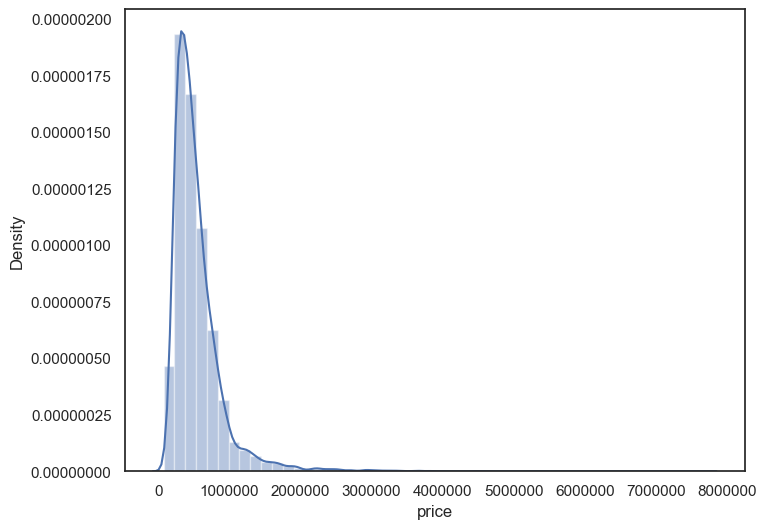

In [207]:
plt.figure(figsize=(8,6))
sns.distplot(df['price'])
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

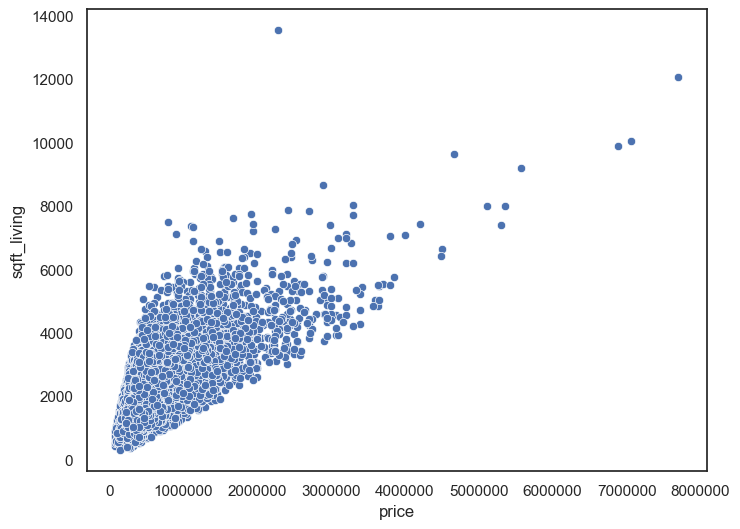

In [208]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='price', y='sqft_living', data=df)
plt.ticklabel_format(style='plain', axis='x')
plt.show()


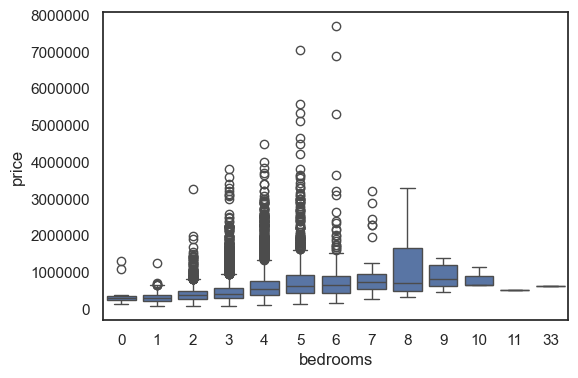

In [212]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

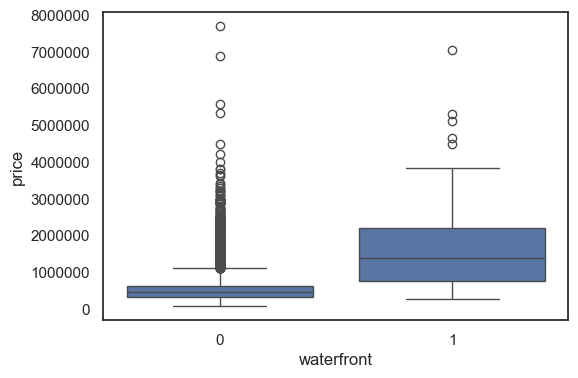

In [213]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='waterfront', y='price', data=df)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

## Working with Feature Data

In [40]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Feature Engineering from Date

In [215]:
#Convert 'date' to date time
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# make columns for month and year
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [217]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,month,year
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,10,2014
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,12,2014
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2,2015
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,12,2014
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2,2015


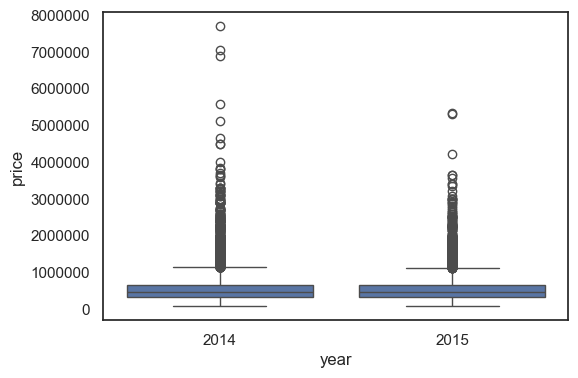

In [221]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='year', y='price', data=df)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

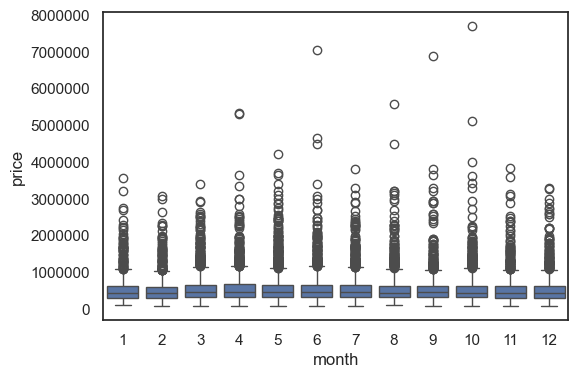

In [222]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='month', y='price', data=df)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [29]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'month', 'year'],
      dtype='object')

## Scaling and Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

### Scaling

In [ ]:
from sklearn.preprocessing

## Creating a Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import

## Training the Model

Train on 15117 samples, validate on 6480 samples
Epoch 1/400
15117/15117 [==============================] - 1s 74us/sample - loss: 430228839929.3955 - val_loss: 418844493758.2617
Epoch 2/400
15117/15117 [==============================] - 0s 21us/sample - loss: 428253102583.9730 - val_loss: 411996069786.8642
Epoch 3/400
15117/15117 [==============================] - 0s 21us/sample - loss: 401401261499.3472 - val_loss: 351554389222.0839
Epoch 4/400
15117/15117 [==============================] - 0s 22us/sample - loss: 281418027052.1653 - val_loss: 178278463958.2815
Epoch 5/400
15117/15117 [==============================] - 0s 21us/sample - loss: 126127754575.5078 - val_loss: 95946680446.4198
Epoch 6/400
15117/15117 [==============================] - 0s 21us/sample - loss: 97670204498.9794 - val_loss: 93708013133.1160
Epoch 7/400
15117/15117 [==============================] - 0s 21us/sample - loss: 95694764310.6754 - val_loss: 91793937901.0370
Epoch 8/400
15117/15117 [=====================

15117/15117 [==============================] - 0s 21us/sample - loss: 32665666133.9938 - val_loss: 31180875164.1284
Epoch 128/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32611257821.4873 - val_loss: 31133322960.5926
Epoch 129/400
15117/15117 [==============================] - 0s 20us/sample - loss: 32587610780.3061 - val_loss: 31109388368.9086
Epoch 130/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32532602761.3225 - val_loss: 31070066824.5333
Epoch 131/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32522762140.2215 - val_loss: 31049869848.0198
Epoch 132/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32456779739.7600 - val_loss: 30991022889.0864
Epoch 133/400
15117/15117 [==============================] - 0s 21us/sample - loss: 32441568509.6800 - val_loss: 31072597773.2741
Epoch 134/400
15117/15117 [==============================] - 0s 20us/sample - loss: 32410024930.5338 - v

15117/15117 [==============================] - 0s 21us/sample - loss: 30409109880.6250 - val_loss: 28668203351.8617
Epoch 254/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30455913509.4593 - val_loss: 28813098750.1037
Epoch 255/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30437949613.1391 - val_loss: 28386738110.2617
Epoch 256/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30388506209.7040 - val_loss: 28367340799.3679
Epoch 257/400
15117/15117 [==============================] - 0s 20us/sample - loss: 30382620658.2491 - val_loss: 28331952921.9160
Epoch 258/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30362880877.7530 - val_loss: 28368884743.5852
Epoch 259/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30377130940.6004 - val_loss: 28326146690.2123
Epoch 260/400
15117/15117 [==============================] - 0s 21us/sample - loss: 30345498520.2249 - v

15117/15117 [==============================] - 0s 21us/sample - loss: 29184432503.5073 - val_loss: 26707127121.5407
Epoch 380/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29192302663.5317 - val_loss: 26916886057.7185
Epoch 381/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29209242404.8666 - val_loss: 26659705383.1901
Epoch 382/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29177634422.7114 - val_loss: 26732598608.2765
Epoch 383/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29162964032.4191 - val_loss: 26640063419.7333
Epoch 384/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29135119725.1095 - val_loss: 26646387926.9136
Epoch 385/400
15117/15117 [==============================] - 0s 20us/sample - loss: 29150060664.3032 - val_loss: 26652868825.4420
Epoch 386/400
15117/15117 [==============================] - 0s 21us/sample - loss: 29143038606.3521 - v

In [47]:
losses = pd.DataFrame(model.history.history)

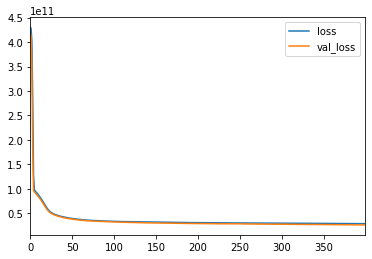

In [48]:
losses.plot()

# Evaluation on Test Data

https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics

In [49]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score

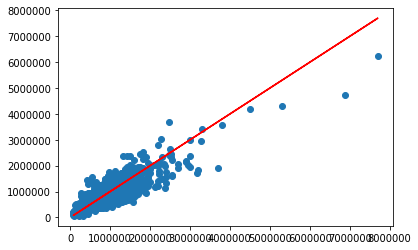